#### Remaining Useful Life Prediction for IGBT Devices
* Data source: NASA, https://data.nasa.gov/dataset/insulated-gate-bipolar-transistor-igbt-accelerated-aging
* Model in/out: Waveform inputs, tabular outputs
* Model choice: BiLSTM + probabilistic model head + NLL loss

#### 1 Load data

In [1]:
import scipy.io
import numpy as np
import pandas as pd

# Load the .mat file
mat_data = scipy.io.loadmat('april22nd-23rdIgbtIRCG40BC30kd-A17.mat')

# The data is stored in the 'measurement' key
measurement = mat_data['measurement']

# Get the list of measurements
measurements = mat_data["measurement"][0, 0][2][0]
num_samples = len(measurements)

# Get feature names from dtype.names
feature_names = list(mat_data["measurement"][0, 0][2][0][0][2].dtype.names)

epochs = []
features = []

for idx in range(num_samples):
    # Extract epoch (scalar)
    epoch = measurements[idx][1][0][0]
    # Extract features and flatten
    feat = np.hstack(measurements[idx][2][0, 0])
    epochs.append(epoch)
    features.append(feat)

# Convert to DataFrame
features_array = np.vstack(features)
df = pd.DataFrame(features_array, columns=feature_names)
df.insert(0, "epoch", epochs)

print(df.head())

          epoch  supplyVoltage  node1Voltage  node2Voltage  \
0  3.291769e+09       3.914292      3.913188      3.308347   
1  3.291769e+09       3.936621      3.933181      3.302764   
2  3.291769e+09       3.939931      3.937010      3.306010   
3  3.291769e+09       3.941944      3.938763      3.307568   
4  3.291769e+09       3.943826      3.939477      3.306140   

   collectorEmitterCurrent  heatSinkTempurature  packageTempurature  
0                 2.917752           129.329910           46.721997  
1                 3.116068           129.329910           47.211104  
2                 3.142162           129.326416           47.282365  
3                 3.142162           129.326416           47.564169  
4                 3.143032           129.329910           47.794146  


Number of cycles (based on filtered consecutive minima): 32


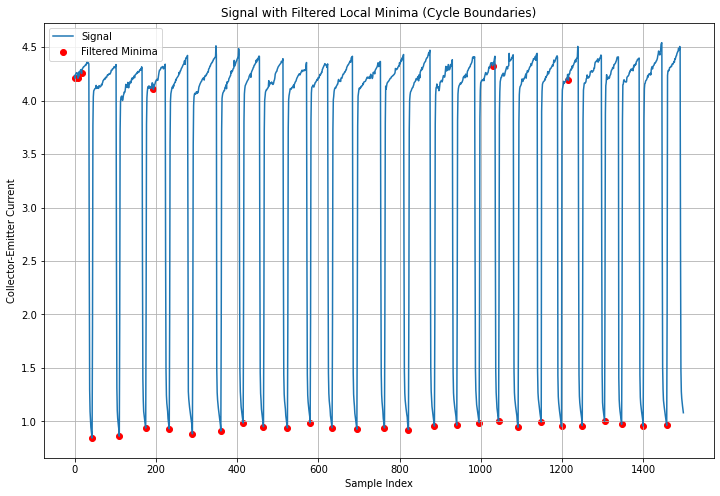

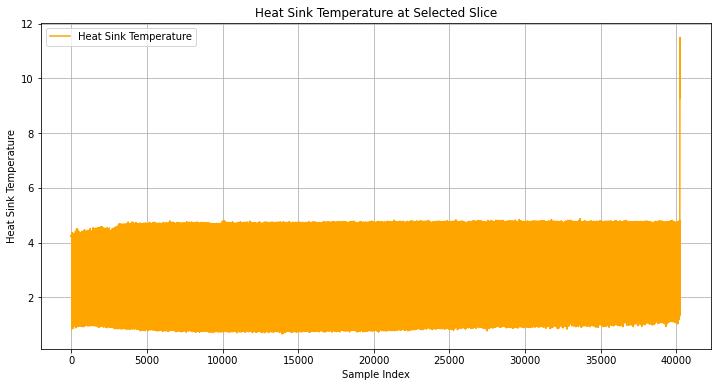

In [3]:
# To count cycles using consecutive minima in the collectorEmitterCurrent signal,
# we can find local minima and count them as cycle boundaries.
# Additionally, filter out spurious minima by checking if each minimum is less than its ambient values within a threshold window.
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

slice_index = slice(1500, 3000)

# Get the signal as a numpy array
signal = df["collectorEmitterCurrent"].values[slice_index]

# Find indices of local minima
minima_indices = argrelextrema(signal, np.less)[0]

# Additional logic: filter out minima that are not sufficiently lower than their ambient values
threshold_steps = 5  # Number of steps to look on each side
min_prominence = 0.01  # Minimum required difference to ambient (adjust as needed)

filtered_minima = []
for idx in minima_indices:
    left = max(0, idx - threshold_steps)
    right = min(len(signal), idx + threshold_steps + 1)
    ambient = np.concatenate([signal[left:idx], signal[idx+1:right]])
    if len(ambient) == 0:
        continue
    # Check if the minimum is less than all ambient values by at least min_prominence
    if np.all(signal[idx] < ambient - min_prominence):
        filtered_minima.append(idx)
filtered_minima = np.array(filtered_minima)

# Number of cycles is the number of filtered minima
num_cycles = len(filtered_minima)

print(f"Number of cycles (based on filtered consecutive minima): {num_cycles}")

plt.figure(figsize=(12, 8))
plt.plot(signal, label="Signal")
plt.scatter(filtered_minima, signal[filtered_minima], color='red', marker='o', label='Filtered Minima')
plt.xlabel("Sample Index")
plt.ylabel("Collector-Emitter Current")
plt.title("Signal with Filtered Local Minima (Cycle Boundaries)")
plt.legend()
plt.grid(True)
plt.show()

# Plot heatSinkTempurature at the same slice_index
heat_sink_temp = (df["collectorEmitterCurrent"].values)[1500:]
# heat_sink_temp = df["packageTempurature"].values[-1500:]
# Plot the heat sink temperature
plt.figure(figsize=(12, 6))
plt.plot(heat_sink_temp, label="Heat Sink Temperature", color='orange')
plt.xlabel("Sample Index")
plt.ylabel("Heat Sink Temperature")
plt.title("Heat Sink Temperature at Selected Slice")
plt.legend()
plt.grid(True)
plt.show()


#### 2 Preprocess Dataset

In [4]:
import numpy as np
from scipy.signal import argrelextrema

# 1. Use argrelextrema and threshold_steps = 5 to select the local minima points for slice index slice(1500, len(df))
slice_start = 1600
slice_index = slice(slice_start, len(df))
signal = df["collectorEmitterCurrent"].values[slice_index]

threshold_steps = 7
min_prominence = 0.01

# Find local minima
minima_indices = argrelextrema(signal, np.less)[0]

# Filter minima
filtered_minima = []
for idx in minima_indices:
    left = max(0, idx - threshold_steps)
    right = min(len(signal), idx + threshold_steps + 1)
    ambient = np.concatenate([signal[left:idx], signal[idx+1:right]])
    if len(ambient) == 0:
        continue
    if np.all(signal[idx] < ambient - min_prominence):
        filtered_minima.append(idx)
filtered_minima = np.array(filtered_minima)

# 2. For each filtered minima index, save the features from the past window_size=100 time steps till the minima index
window_size = 200
feature_columns = ["node1Voltage", "node2Voltage", "collectorEmitterCurrent", "packageTempurature"]

X = []
y = []

for i, minima_idx in enumerate(filtered_minima):
    # Make sure we have enough history for the window
    if minima_idx - window_size + 1 < 0:
        continue
    # Get the window indices in the original df
    window_indices = np.arange(minima_idx - window_size + 1, minima_idx + 1) + slice_start
    # Extract the features for this window
    window_features = df.iloc[window_indices][feature_columns].values  # shape: (window_size, num_features)
    X.append(window_features)
    # 3. The output data is the number of cycles left till the end
    cycles_left = len(filtered_minima) - i - 1
    y.append(cycles_left)

X = np.array(X)  # shape: (num_samples, window_size, num_features)
y = np.array(y)  # shape: (num_samples,)

# 4. Print it out
print("Input data shape (num_samples, window_size, num_features):", X.shape)
print("Output data shape (num_samples,):", y.shape)
print("Example input (first sample):")
print(X[0])
print("Example output (first sample):", y[0])


Input data shape (num_samples, window_size, num_features): (1170, 200, 4)
Output data shape (num_samples,): (1170,)
Example input (first sample):
[[  3.94428053   3.08732436   4.28856773 329.40406678]
 [  3.94174899   3.08972607   4.28247908 329.53363259]
 [  3.94428053   3.08661034   4.2981356  329.65348097]
 [  3.94415071   3.08764892   4.28856773 329.85106883]
 [  3.94363142   3.08544194   4.31553174 329.74417704]
 [  3.94441035   3.08336479   4.30074503 330.09724388]
 [  3.9464226    3.43193722   2.55504254 330.28835345]
 [  3.94830502   3.66152773   1.40080878 330.32398405]
 [  3.94843484   3.70333048   1.2007532  330.46326731]
 [  3.94908395   3.72591954   1.09463676 330.38552782]
 [  3.9487594    3.73351414   1.05897468 330.26244029]
 [  3.94895413   3.73922632   1.02505221 330.22357055]
 [  3.94888922   3.74597708   0.99634858 330.00330866]
 [  3.94895413   3.75129979   0.96590534 329.80895994]
 [  3.94914886   3.75707687   0.93807152 329.67939413]
 [  3.9464226    3.53715809  

#### 3 Define Probabilistic BiLSTM NN and Tune Hyperparameters

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Split the dataset into train, val, test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42
)  # 0.1765*0.85 ≈ 0.15

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

# 2. Scalerization (fit scaler on train, apply to all)
num_features = X.shape[2]
scaler_X = StandardScaler()
X_train_2d = X_train.reshape(-1, num_features)
scaler_X.fit(X_train_2d)

def scale_X(X, scaler):
    orig_shape = X.shape
    X_2d = X.reshape(-1, orig_shape[2])
    X_scaled_2d = scaler.transform(X_2d)
    return X_scaled_2d.reshape(orig_shape)

X_train_scaled = scale_X(X_train, scaler_X)
X_val_scaled = scale_X(X_val, scaler_X)
X_test_scaled = scale_X(X_test, scaler_X)

# Output scalerization (fit on train, apply to all)
scaler_y = StandardScaler()
y_train_reshaped = y_train.reshape(-1, 1)
scaler_y.fit(y_train_reshaped)

def scale_y(y, scaler):
    y_reshaped = y.reshape(-1, 1)
    y_scaled = scaler.transform(y_reshaped)
    return y_scaled.flatten()

y_train_scaled = scale_y(y_train, scaler_y)
y_val_scaled = scale_y(y_val, scaler_y)
y_test_scaled = scale_y(y_test, scaler_y)

# 3. Convert to torch tensors and create DataLoaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def to_tensor(x, y):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    return x_tensor, y_tensor

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train_scaled)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val_scaled)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test_scaled)

batch_size = 200
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# 4. Define probabilistic biLSTM model in PyTorch (outputs mean and log-variance)
class ProbabilisticBiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, hidden_size2=16, num_layers=1):
        super().__init__()
        self.bilstm1 = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.ln1 = nn.LayerNorm(hidden_size*2)
        self.bilstm2 = nn.LSTM(hidden_size*2, hidden_size2, num_layers=1, batch_first=True, bidirectional=True)
        self.ln2 = nn.LayerNorm(hidden_size2*2)
        self.fc1 = nn.Linear(hidden_size2*2, 16)
        self.relu = nn.ReLU()
        self.fc_mean = nn.Linear(16, 1)
        self.fc_logvar = nn.Linear(16, 1)
        
    def forward(self, x):
        out, _ = self.bilstm1(x)
        out = self.ln1(out)
        out, _ = self.bilstm2(out)
        out = self.ln2(out)
        out = out[:, -1, :]  # Take last time step
        out = self.fc1(out)
        out = self.relu(out)
        mean = self.fc_mean(out)
        logvar = self.fc_logvar(out)
        return mean, logvar

model = ProbabilisticBiLSTMRegressor(input_size=num_features).to(device)
print(model)

# 5. Training setup: Negative log-likelihood loss for Gaussian output
def gaussian_nll_loss(y_pred_mean, y_pred_logvar, y_true):
    # y_pred_mean, y_pred_logvar, y_true: (batch, 1)
    # NLL = 0.5 * log(2*pi) + 0.5*logvar + 0.5*((y - mean)^2 / exp(logvar))
    nll = 0.5 * torch.log(2 * torch.tensor(torch.pi)) + 0.5 * y_pred_logvar + 0.5 * ((y_true - y_pred_mean) ** 2) / torch.exp(y_pred_logvar)
    return nll.mean()

# Start with lr=1e-2, halve every 10 epochs
initial_lr = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
num_epochs = 200

# 6. Training loop with early stopping and learning rate annealing
best_val_loss = float('inf')

for epoch in range(num_epochs):
    # Anneal learning rate: halve every 20 epochs
    if epoch > 0 and epoch % 20 == 0:
        if optimizer.param_groups[0]['lr'] > 1e-4:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.5
            print(f"Learning rate annealed to {optimizer.param_groups[0]['lr']:.6f} at epoch {epoch+1}")

    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        mean, logvar = model(xb)
        loss = gaussian_nll_loss(mean, logvar, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    train_loss = sum(train_losses) / len(train_losses)
    
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            mean, logvar = model(xb)
            loss = gaussian_nll_loss(mean, logvar, yb)
            val_losses.append(loss.item())
    val_loss = sum(val_losses) / len(val_losses)
    print(f"Epoch {epoch+1}: Train NLL={train_loss:.4f}, Val NLL={val_loss:.4f}, LR={optimizer.param_groups[0]['lr']:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

# Load best model
model.load_state_dict(best_model_state)


Train shape: (818, 200, 4) (818,)
Val shape: (176, 200, 4) (176,)
Test shape: (176, 200, 4) (176,)
ProbabilisticBiLSTMRegressor(
  (bilstm1): LSTM(4, 32, batch_first=True, bidirectional=True)
  (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (bilstm2): LSTM(64, 16, batch_first=True, bidirectional=True)
  (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc_mean): Linear(in_features=16, out_features=1, bias=True)
  (fc_logvar): Linear(in_features=16, out_features=1, bias=True)
)
Epoch 1: Train NLL=1.4416, Val NLL=1.4217, LR=0.010000
Epoch 2: Train NLL=1.3990, Val NLL=1.4250, LR=0.010000
Epoch 3: Train NLL=1.3997, Val NLL=1.4399, LR=0.010000
Epoch 4: Train NLL=1.4230, Val NLL=1.4122, LR=0.010000
Epoch 5: Train NLL=1.4312, Val NLL=1.4111, LR=0.010000
Epoch 6: Train NLL=1.3789, Val NLL=1.4068, LR=0.010000
Epoch 7: Train NLL=1.4237, Val NLL=1.4025, LR=0.010000
Epoch 8: Train NLL=1.4050, V

<All keys matched successfully>

Test NLL (scaled): 0.1711, Test MAE (original scale): 81.6137


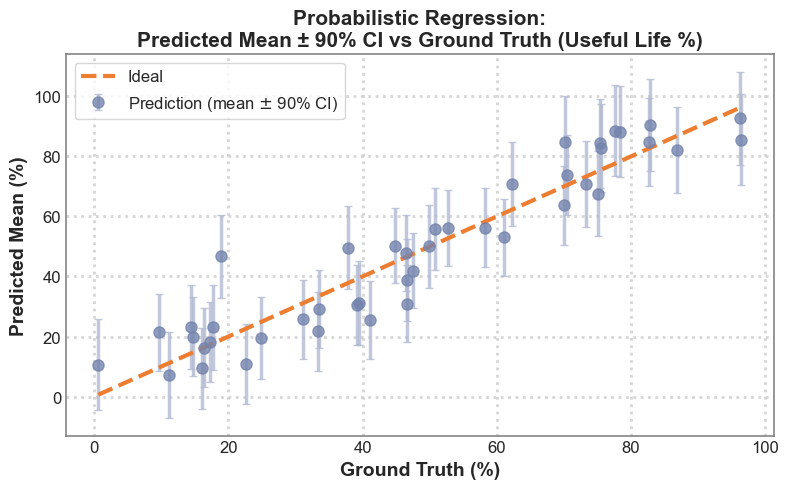

Percentage of ground truth within 90% CI of prediction: 93.18%


In [ ]:
# Evaluate on test set
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import torch

# Use a nice style for all plots
plt.style.use('seaborn-v0_8-whitegrid')

model.eval()
test_losses = []
mae_losses = []
all_means = []
all_stds = []
all_targets = []
test_inputs = []  # To store all test inputs in order
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        mean, logvar = model(xb)
        loss = gaussian_nll_loss(mean, logvar, yb)
        test_losses.append(loss.item())
        # Inverse transform predictions and targets for MAE in original scale
        mean_np = mean.cpu().numpy()
        std_np = np.sqrt(np.exp(logvar.cpu().numpy()))
        yb_np = yb.cpu().numpy()
        mean_inv = scaler_y.inverse_transform(mean_np)
        std_inv = std_np * scaler_y.scale_[0]  # std in original scale
        yb_inv = scaler_y.inverse_transform(yb_np)
        mae = np.mean(np.abs(mean_inv - yb_inv))
        mae_losses.append(mae)
        all_means.append(mean_inv)
        all_stds.append(std_inv)
        all_targets.append(yb_inv)
        test_inputs.append(xb.cpu().numpy())
test_nll = sum(test_losses) / len(test_losses)
test_mae = sum(mae_losses) / len(mae_losses)
print(f"Test NLL (scaled): {test_nll:.4f}, Test MAE (original scale): {test_mae:.4f}")

# Convert from remaining cycles to remaining useful life (%) for plot axes
# Assumes max_remaining_cycles is the expected full useful life (in cycles)
max_remaining_cycles = np.max(np.concatenate(all_targets + all_means, axis=0))

all_means_flat = np.concatenate(all_means, axis=0).flatten()
all_stds_flat = np.concatenate(all_stds, axis=0).flatten()
all_targets_flat = np.concatenate(all_targets, axis=0).flatten()
test_inputs_flat = np.concatenate(test_inputs, axis=0)  # shape: (N, ?)

# Convert to percentage of useful life remaining
all_means_pct = (all_means_flat / max_remaining_cycles) * 100
all_targets_pct = (all_targets_flat / max_remaining_cycles) * 100
all_stds_pct = (all_stds_flat / max_remaining_cycles) * 100

# Randomly select 25% of test data for plotting (as before)
num_samples = len(all_targets_pct)
num_to_plot = max(1, int(np.ceil(0.25 * num_samples)))
rng = np.random.default_rng(seed=42)
indices = rng.choice(num_samples, num_to_plot, replace=False)

plot_means_pct = all_means_pct[indices]
plot_targets_pct = all_targets_pct[indices]
plot_stds_pct = all_stds_pct[indices]

z_score_90 = norm.ppf(0.95)  # z value for 90% CI (two-sided, i.e., 5% upper tail)
ci_90_radius_pct = z_score_90 * plot_stds_pct

# Custom colors
dot_color = '#7484AD'
ideal_color = '#ED7D31'
# Lighter variant of #7484AD for CI error bars
from matplotlib.colors import to_rgb
def lighten_color(color, amount=0.5):
    c = np.array(to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)
ci_color = lighten_color(dot_color, 0.45)

fig, ax = plt.subplots(figsize=(8, 5), dpi=100)  # Increased dpi for improved quality

# Plot error bars (confidence intervals) with custom color
ax.errorbar(
    plot_targets_pct,
    plot_means_pct,
    yerr=ci_90_radius_pct,
    fmt='o',
    markersize=8,
    markerfacecolor=dot_color,
    markeredgecolor=dot_color,
    color=ci_color,
    ecolor=ci_color,
    elinewidth=2.5,
    capsize=3,
    alpha=0.8,
    label=r'Prediction (mean $\pm$ 90% CI)'
)

# Plot ideal line with custom color
ax.plot([plot_targets_pct.min(), plot_targets_pct.max()],
        [plot_targets_pct.min(), plot_targets_pct.max()],
        color=ideal_color,
        linestyle='--',
        linewidth=3,
        label='Ideal')

# Styling
ax.set_xlabel('Ground Truth (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Mean (%)', fontsize=14, fontweight='bold')
ax.set_title('Probabilistic Regression:\nPredicted Mean ± 90% CI vs Ground Truth (Useful Life %)',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True, fancybox=True)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle=':', linewidth=2, alpha=0.8)

# Set a nice background and border
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1.1)
    spine.set_edgecolor('#7B7B7B')

plt.tight_layout()
plt.show()

# Additional evaluation: percentage of ground-truth within 90% confidence interval
lower_bound = all_means_flat - z_score_90 * all_stds_flat
upper_bound = all_means_flat + z_score_90 * all_stds_flat
within_90 = (all_targets_flat >= lower_bound) & (all_targets_flat <= upper_bound)
percent_within_90 = np.mean(within_90) * 100
print(f"Percentage of ground truth within 90% CI of prediction: {percent_within_90:.2f}%")


Sample [~80% useful life] (index 2):
  Target Useful Life: 78.43%
  Predicted Mean: 88.28%
  Predicted Std: 9.29%
  90% CI Range: [73.00%, 103.56%]

Sample [~20% useful life] (index 33):
  Target Useful Life: 18.90%
  Predicted Mean: 46.71%
  Predicted Std: 8.35%
  90% CI Range: [32.97%, 60.45%]

Showing both distribution plots for samples closest to 80% and 20% useful life, with 90% CI shaded.


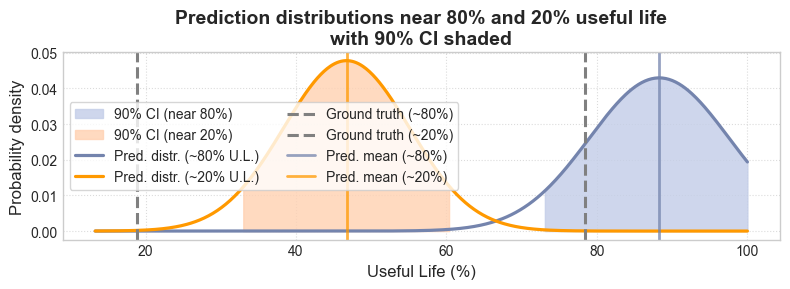

In [ ]:
# --- Additional Section: Print sample cases near 80% and 20% useful life ---

# Prepare mask for displayed samples
plot_targets_full = plot_targets_pct
plot_means_full = plot_means_pct
plot_stds_full = plot_stds_pct

# Find indices of closest displayed points to 80% and 20%
def find_closest_idx(arr, value):
    arr = np.asarray(arr)
    return np.argmin(np.abs(arr - value))

idx_80 = find_closest_idx(plot_targets_full, 80.0)
idx_20 = find_closest_idx(plot_targets_full, 20.0)

def summary_case(idx, label):
    gt = plot_targets_full[idx]
    pred = plot_means_full[idx]
    std = plot_stds_full[idx]
    ci_low = pred - z_score_90 * std
    ci_high = pred + z_score_90 * std
    print(f"\nSample [{label}] (index {idx}):")
    print(f"  Target Useful Life: {gt:.2f}%")
    print(f"  Predicted Mean: {pred:.2f}%")
    print(f"  Predicted Std: {std:.2f}%")
    print(f"  90% CI Range: [{ci_low:.2f}%, {ci_high:.2f}%]")

summary_case(idx_80, "~80% useful life")
summary_case(idx_20, "~20% useful life")

# --- NEW SECTION: Save the inputs of the selected two cases locally ---

import os
import pandas as pd

# Map displayed indices back to indices in the whole test set
input_index_80 = indices[idx_80]
input_index_20 = indices[idx_20]

input_80 = test_inputs_flat[input_index_80]
input_20 = test_inputs_flat[input_index_20]

# --- Plot both distributions on the same figure, highlight each 90% CI ---

# Get selected cases' stats
mean_80 = plot_means_full[idx_80]
std_80 = plot_stds_full[idx_80]
target_80 = plot_targets_full[idx_80]

mean_20 = plot_means_full[idx_20]
std_20 = plot_stds_full[idx_20]
target_20 = plot_targets_full[idx_20]

print("\nShowing both distribution plots for samples closest to 80% and 20% useful life, with 90% CI shaded.")

# X-axis range to fit both distributions well
x_all_min = max(0, min(mean_80 - 4*std_80, mean_20 - 4*std_20))
x_all_max = min(100, max(mean_80 + 4*std_80, mean_20 + 4*std_20))
x = np.linspace(x_all_min, x_all_max, 600)

# Calculate PDFs
pdf_80 = norm.pdf(x, mean_80, std_80)
ci_low_80, ci_high_80 = mean_80 - z_score_90 * std_80, mean_80 + z_score_90 * std_80

pdf_20 = norm.pdf(x, mean_20, std_20)
ci_low_20, ci_high_20 = mean_20 - z_score_90 * std_20, mean_20 + z_score_90 * std_20

fig, ax = plt.subplots(figsize=(8, 3), dpi=100)

# Fill 90% CIs
mask_ci_80 = (x >= ci_low_80) & (x <= ci_high_80)
ax.fill_between(x[mask_ci_80], 0, pdf_80[mask_ci_80], color="#C4CEE8", alpha=0.82, 
                label="90% CI (near 80%)")

mask_ci_20 = (x >= ci_low_20) & (x <= ci_high_20)
ax.fill_between(x[mask_ci_20], 0, pdf_20[mask_ci_20], color="#FFD2B3", alpha=0.82, 
                label="90% CI (near 20%)")

# Plot PDFs
ax.plot(x, pdf_80, color="#7484AD", linewidth=2.3, label="Pred. distr. (~80% U.L.)")
ax.plot(x, pdf_20, color="#FF9900", linewidth=2.3, label="Pred. distr. (~20% U.L.)")

# Plot target lines with the same dashed grey line style
ax.axvline(target_80, color='grey', linestyle='--', linewidth=2.2, label='Ground truth (~80%)')
ax.axvline(target_20, color='grey', linestyle='--', linewidth=2.2, label='Ground truth (~20%)')

# Plot means
ax.axvline(mean_80, color="#7484AD", linestyle='-', linewidth=2.0, alpha=0.75, label='Pred. mean (~80%)')
ax.axvline(mean_20, color="#FF9900", linestyle='-', linewidth=2.0, alpha=0.75, label='Pred. mean (~20%)')

# Styling
ax.set_ylabel("Probability density", fontsize=12)
ax.set_xlabel("Useful Life (%)", fontsize=12)
ax.set_title("Prediction distributions near 80% and 20% useful life\nwith 90% CI shaded", fontsize=14, fontweight='bold')
ax.legend(fontsize=10, frameon=True, fancybox=True, ncol=2)
ax.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()